In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from collections import Counter

In [2]:
with open("schaefer_parcel_counts.pkl", 'rb') as f:
    parcel_voxel_counts = pickle.load(f)
    
with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
    schaefer_parcel_labels = pickle.load(f)
    
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/all_results.pkl", 'rb') as f:
    records = pickle.load(f)
    
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/participant_means.pkl", 'rb') as f:
    participant_means = pickle.load(f)
    
# inpath = '/data/zachkaras/fmri_model_data/intermediate_results' 
# with open(f"{inpath}/enrichment_analysis_results.pkl", 'rb') as f:
#     enriched_parcels = pickle.load(f)

model_labels = {
    'deepseek_6b' : 'DeepSeek 6B',
}

task_labels = {
    'code' : 'Code',
    'prose': 'Prose'
}

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")


In [3]:
demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")

In [19]:
important_participants = ['117', '125', '108']

def translate_to_region_names(parcel_num, schaefer_labels):
        parcel_num = int(parcel_num)
        if parcel_num <= 200:
            region = f"Left {schaefer_labels['left'][parcel_num]}"
        else:
            region = f"Right {schaefer_labels['right'][parcel_num]}"
        return region

def get_top_five_regions(parcel_dict):
    parcel_dict = dict(sorted(parcel_dict.items(), key= lambda x: x[1], reverse=True))
    return {region : val for i,(region,val) in enumerate(parcel_dict.items()) if i < 5}

def plot_participant_parcels_across_layers(p, model, task, parcel_dict, region_colors, jaccard):
    # Build rows, sorting each layer's regions by score descending
    rows = []
    for _, row in parcel_dict.iterrows():
        layer = str(row['layer'])
        sorted_regions = sorted(row['top_five_regions'].items(), key=lambda x: x[1], reverse=True)[:5]
        for rank, (region, val) in enumerate(sorted_regions):
            rows.append({'layer': layer, 'region': region, 'score': val, 'rank': rank})
    df = pd.DataFrame(rows)
    # print(df)

    layers = sorted(df['layer'].unique(), key=lambda x: int(x.split('_')[1]))
    layer_labels = [x.split('_')[1] for x in layers]

    n_bars = 5
    bar_width = 0.15
    gap = 0.3  # extra space between groups

    fig, ax = plt.subplots(figsize=(14, 8))
    group_centers = []

    for g_idx, layer in enumerate(layers):
        layer_df = df[df['layer'] == layer].sort_values('score', ascending=False)
        n = len(layer_df)
        offsets = np.arange(n) * bar_width - (n - 1) * bar_width / 2
        center = g_idx * (n_bars * bar_width + gap)
        group_centers.append(center)
        for b_idx, (_, r) in enumerate(layer_df.iterrows()):
            ax.bar(center + offsets[b_idx], r['score'], width=bar_width,
                   color=region_colors[r['region']], edgecolor='black',
                   label=r['region'])

    # Deduplicated legend (first occurrence of each region)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Region", loc='lower left', fontsize=12)

    ax.set_xticks(group_centers)
    # ax.set_xticklabels(layers, rotation=45, ha='right')
    ax.set_xticklabels(layer_labels, ha='right', fontsize=14)
    ax.set_xlabel("Layer", fontsize=14)
    # ax.set_ylim([0, 25])
    ax.set_ylabel("Voxels Among Top 10K Per Region", fontsize=14)
    ax.set_title(f"Top Regions Modeled Per Layer - Participant {p}\n{model_labels[model]}-{task_labels[task]} - Jaccard Index: {jaccard:.3f}", fontsize=20)
    plt.tight_layout()
    # plt.savefig(f"/data/zachkaras/fmri_model_data/plots/layer_regions-{p}-{task}.png", dpi=200)
    plt.savefig(f"/tank/home/zachkaras/fmri_model_data/plots/layer_regions-{p}-{task}.png", dpi=200)
    plt.show()


def compute_jaccard(df):
    list_of_sets = [set(row['top_five_regions'].keys()) for i,row in df.iterrows()]
    intersection = set.intersection(*list_of_sets)
    union = set.union(*list_of_sets)
    return len(intersection) / len(union)
        

In [15]:
all_regions_global = set()
for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        for top_five in df['top_five_regions']:
            all_regions_global.update(top_five.keys())

all_regions_global = sorted(all_regions_global)  # sort for deterministic ordering
palette = sns.color_palette("rainbow", len(all_regions_global))
rng = np.random.default_rng(seed=1) # 111 is pretty good
rng.shuffle(palette)
region_colors = {r: palette[i] for i, r in enumerate(all_regions_global)}

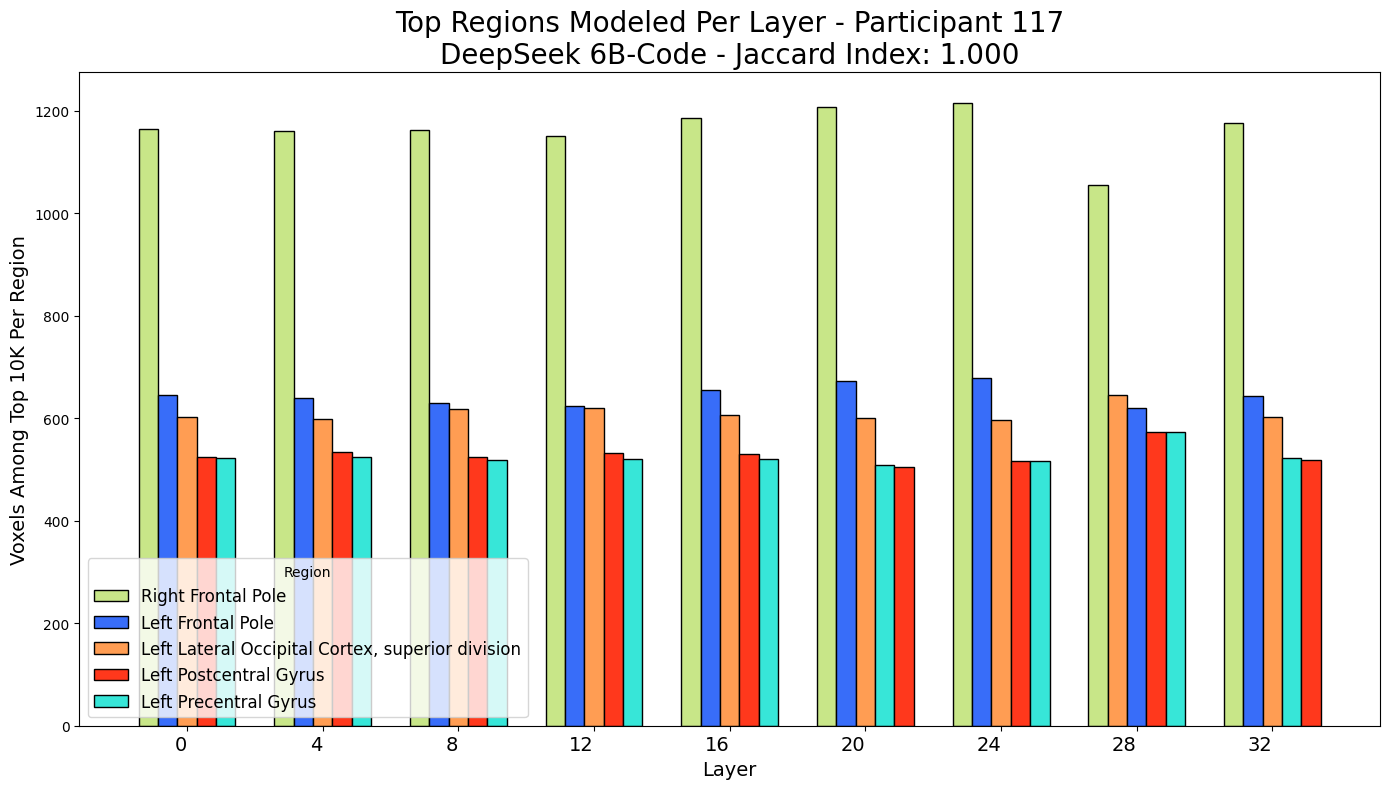

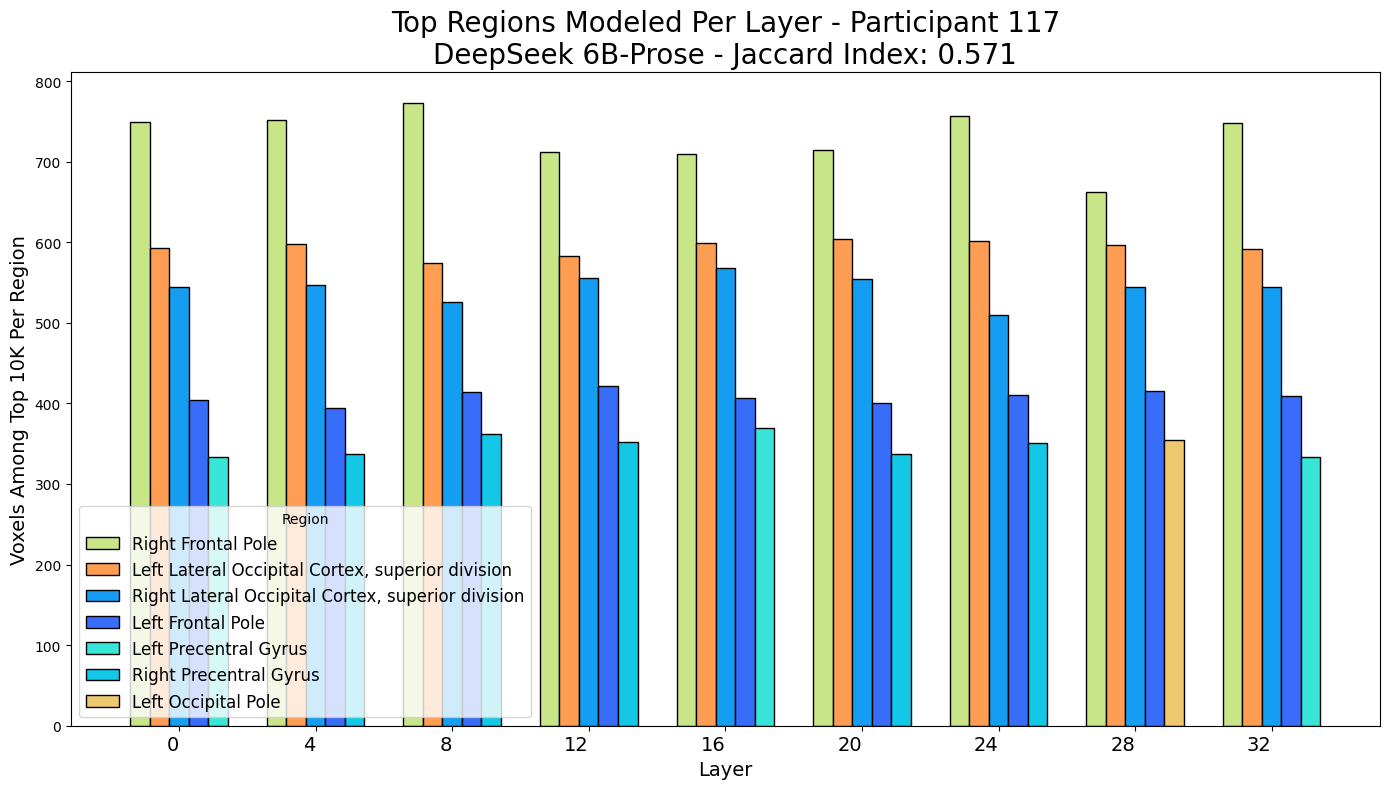

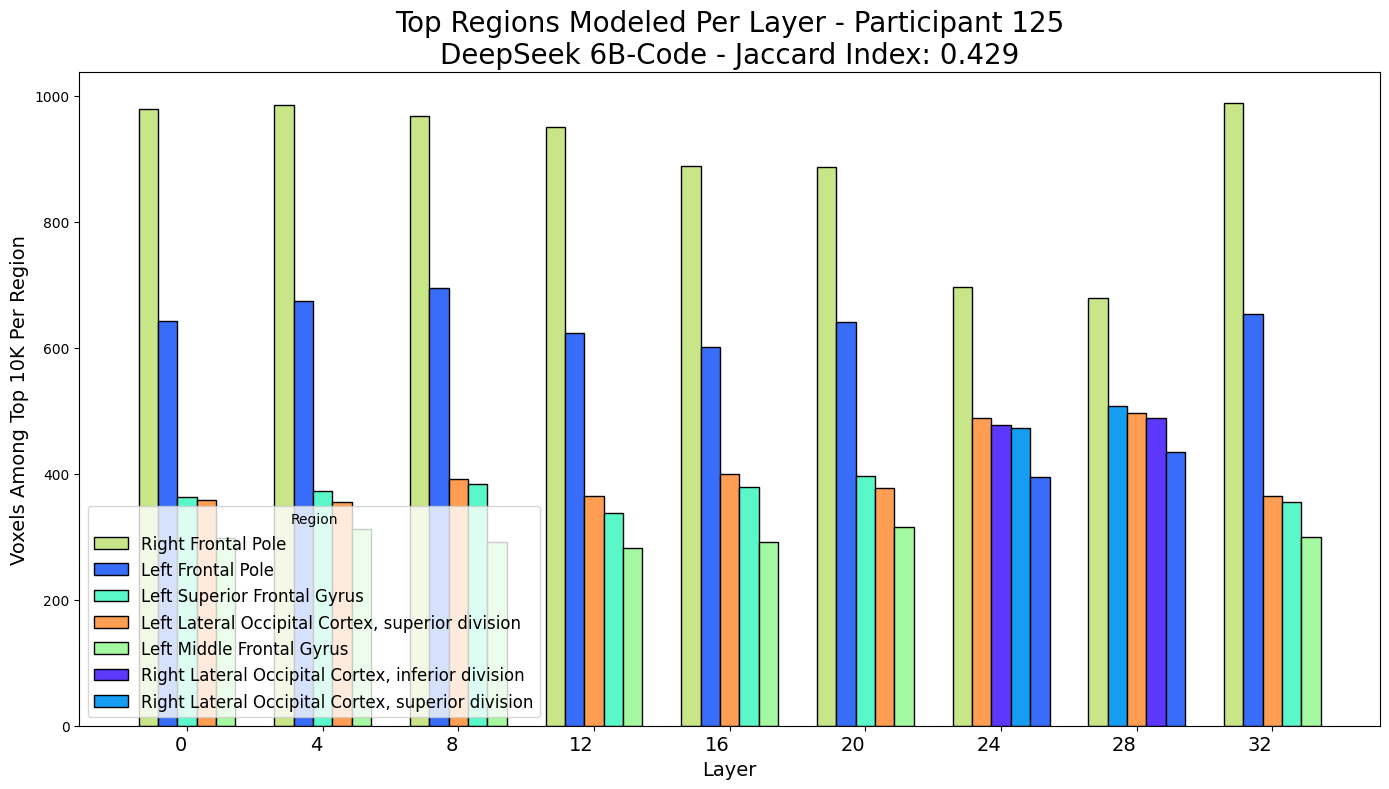

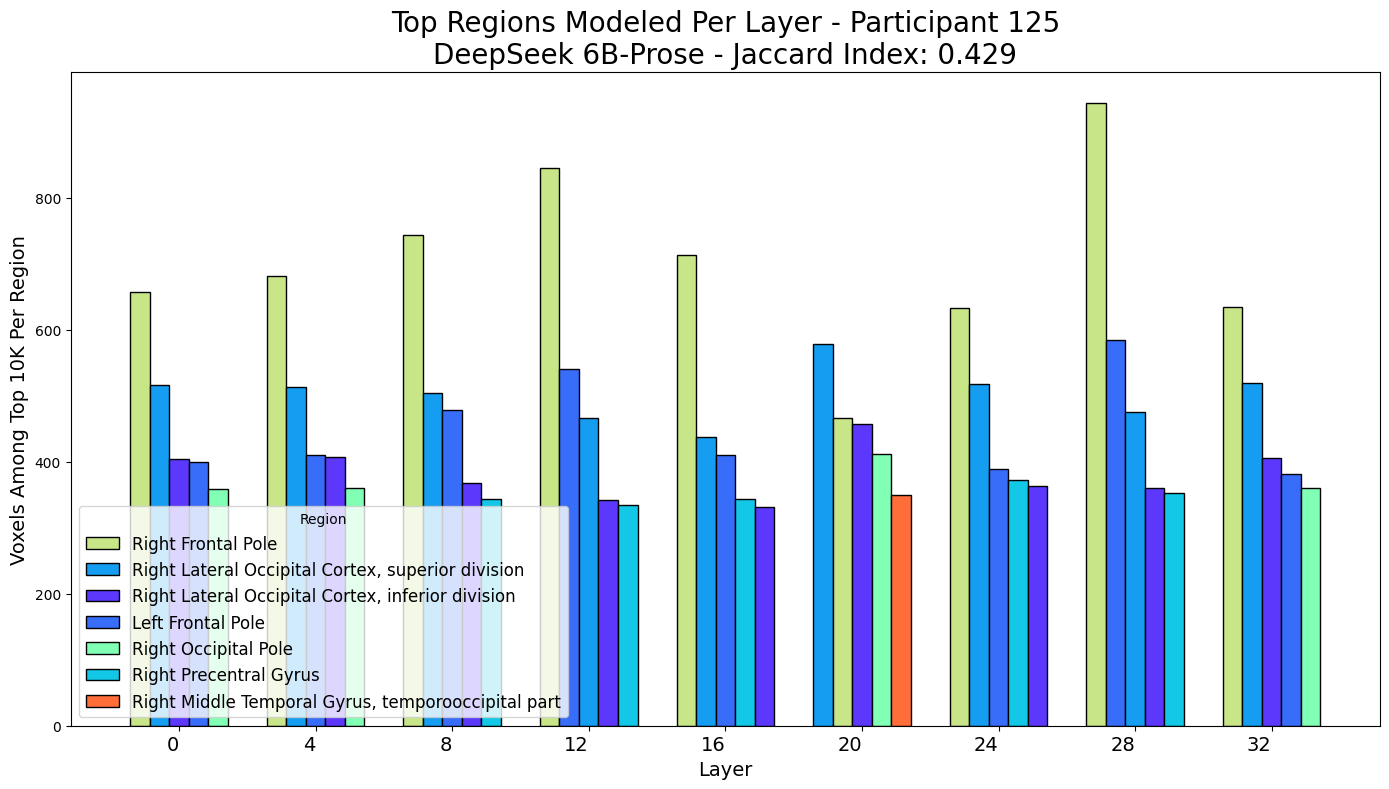

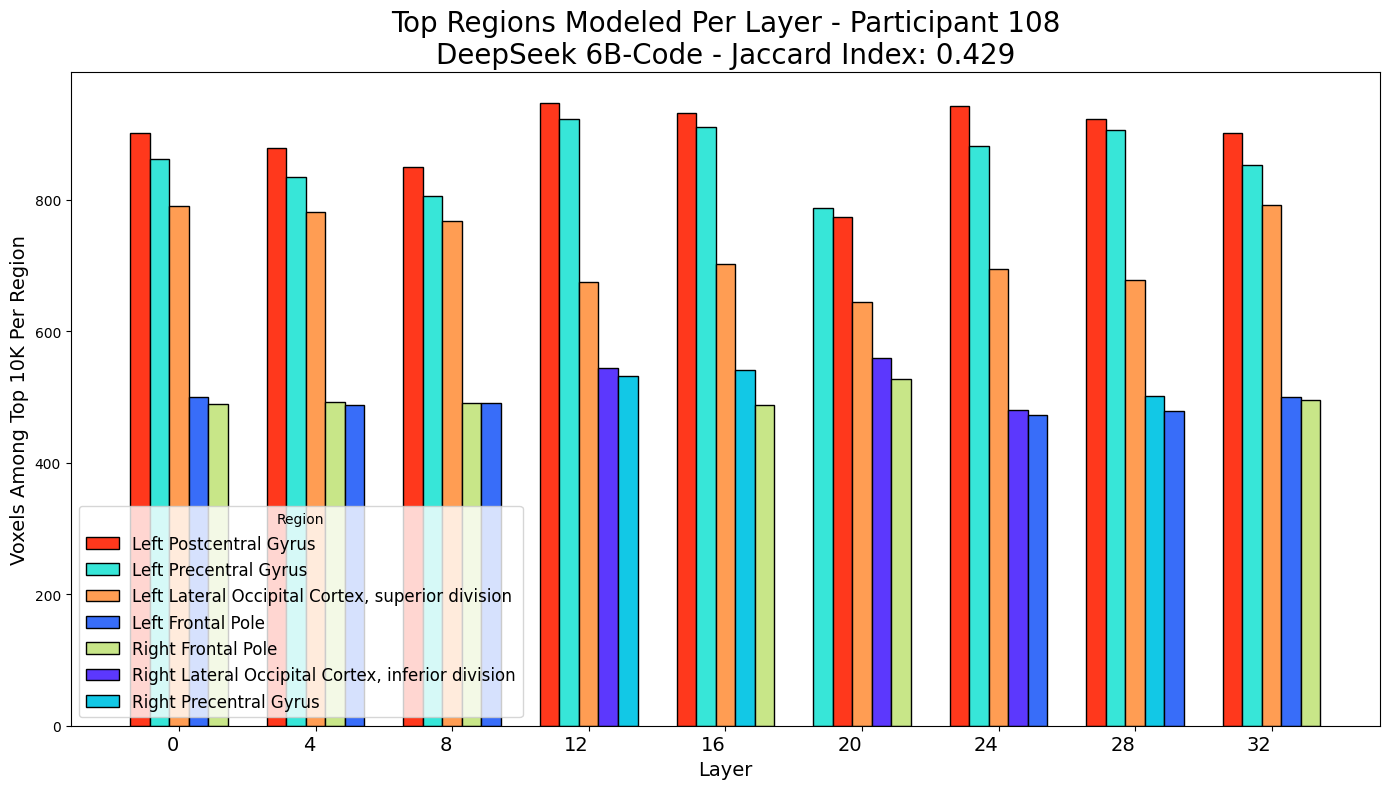

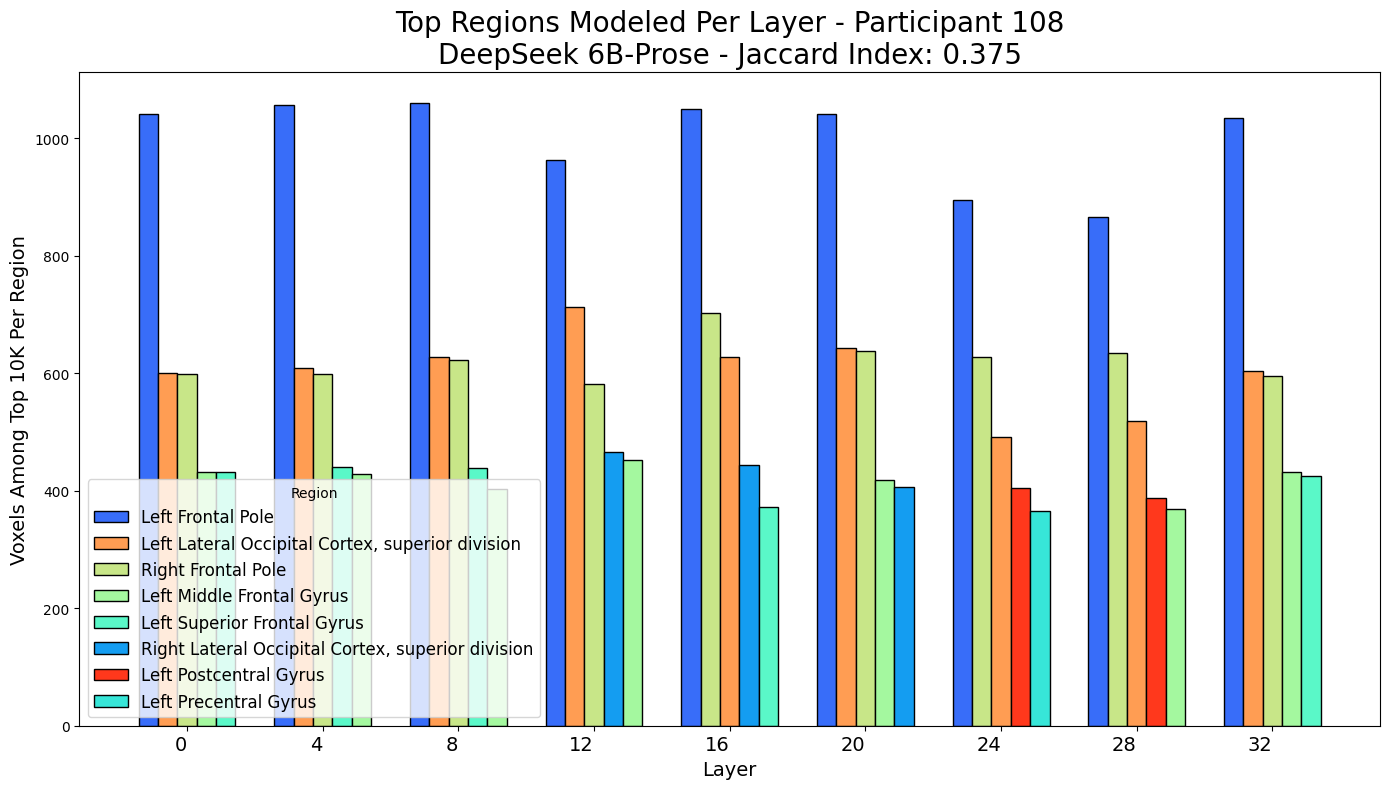

In [20]:

for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        filtered = df[['layer', 'top_five_regions']].copy()
        filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))
        jaccard_index = compute_jaccard(filtered)
    #     break
    # break
        plot_participant_parcels_across_layers(vip, model, task, filtered, region_colors, jaccard_index)


In [ ]:
# TODO - correlation between jaccard index and performance

In [71]:
participants = os.listdir("midprocess")
top_five_regions = {
    'code' : {},
    'prose': {}
}
for p in participants:
    mask = ((records['participant'] == p) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        # explode by layer
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        top_five_regions[task][p] = set(df['top_five_regions'].explode())

In [73]:
with open('typing_counts.pkl', 'rb') as f:
    typing_counts = pickle.load(f)
    

# Add keystroke-based variables to demo_data (separately for code and prose)
for pid_str, tasks in typing_counts.items():
    pid = int(pid_str)
    for task in ['code', 'prose']:
        try:
            total_keys = tasks[task]['total_keys_pressed']
        except:
            print(f"No {task} task for {pid}.")
            continue
        total_backspaces = tasks[task]['total_backspaces']
        mask = demo_data['id'] == pid
        demo_data.loc[mask, f'{task}_total_keystrokes'] = total_keys
        demo_data.loc[mask, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')


No prose task for 101.
No code task for 130.


/tmp/ipykernel_36495/216352652.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  demo_data.loc[mask, f'{task}_total_keystrokes'] = total_keys
/tmp/ipykernel_36495/216352652.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  demo_data.loc[mask, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')
/tmp/ipykernel_36495/216352652.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider

In [ ]:
def compute_jaccard_similarity(task, p1, p2):
    p1_regions = top_five_regions[task][p1]
    p2_regions = top_five_regions[task][p2]
    intersection = set.intersection(p1_regions, p2_regions)
    union = set.union(p1_regions, p2_regions)
    return len(intersection) / len(union)

def get_demo_value(p, col):
    """Look up a demo_data value by participant ID string, return inf for NaN (sorts last)."""
    rows = demo_data.loc[demo_data['id'] == int(p), col]
    if rows.empty:
        return float('inf')
    val = rows.values[0]
    return float('inf') if pd.isna(val) else val

def plot_jaccard(task, sort_by, matrix):
    fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                                                 
    sns.heatmap(matrix, annot_kws={"size":14, "weight":"bold"}, fmt= '', cmap='rainbow', ax=ax)
    ax.set_title(f"{task_labels[task]} — Similarity in Top Regions", fontsize=20)
    ax.set_xlabel("Participant")                                                                                                                                                                            
    ax.set_ylabel("Participant")                                                                                                                                                                   
    plt.tight_layout()       
    plt.savefig(f'/tank/home/zachkaras/fmri_model_data/plots/jaccard_matrix-{task}-{sort_by}.png', dpi=200)                                                                                                                                                                              
    plt.show() 

def create_jaccard_matrix(task, sort_by):
    participants = [pid for pid in list(top_five_regions['code'].keys()) if pid in list(top_five_regions['prose'].keys())]
    if sort_by in ['code_editing_rate', 'prose_editing_rate']:
        participants_sorted = sorted(participants, key=lambda p: get_demo_value(p, sort_by), reverse=True)
    elif sort_by == 'none':
        participants_sorted = participants
    else:
        participants_sorted = sorted(participants, key=lambda p: get_demo_value(p, sort_by))
    n = len(participants_sorted)

    jaccard_matrix = pd.DataFrame(
        np.zeros((n, n)),
        index=participants_sorted,
        columns=participants_sorted
    )

    for p1 in participants_sorted:
        for p2 in participants_sorted:
            jaccard_matrix.loc[p1, p2] = compute_jaccard_similarity(task, p1, p2)
    
    plot_jaccard(task, sort_by, jaccard_matrix)


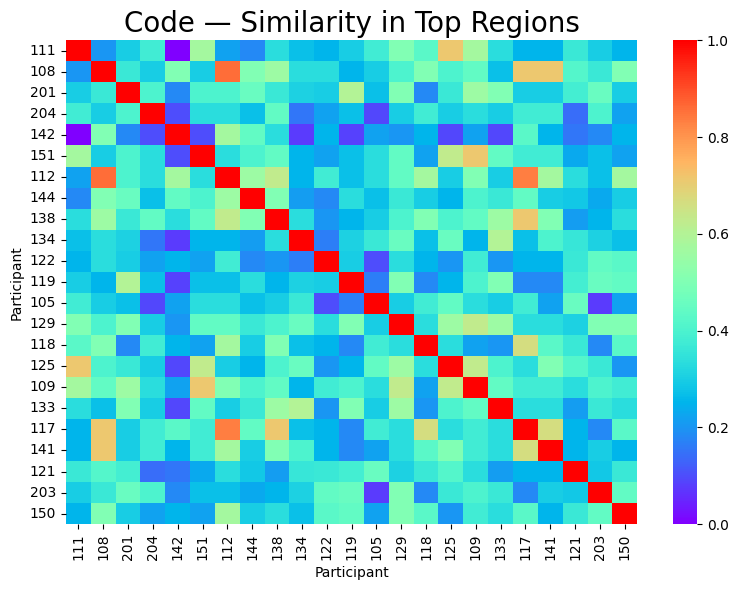

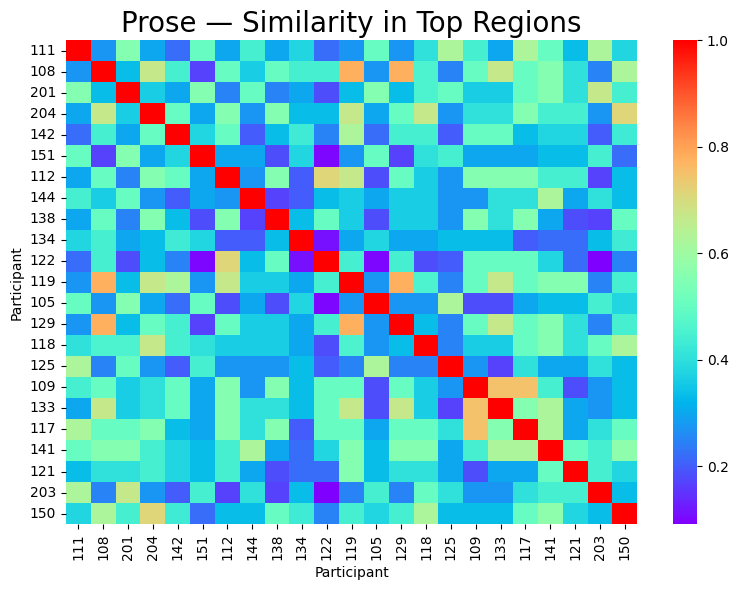

In [104]:
create_jaccard_matrix('code', sort_by='none')
create_jaccard_matrix('prose', sort_by='none')

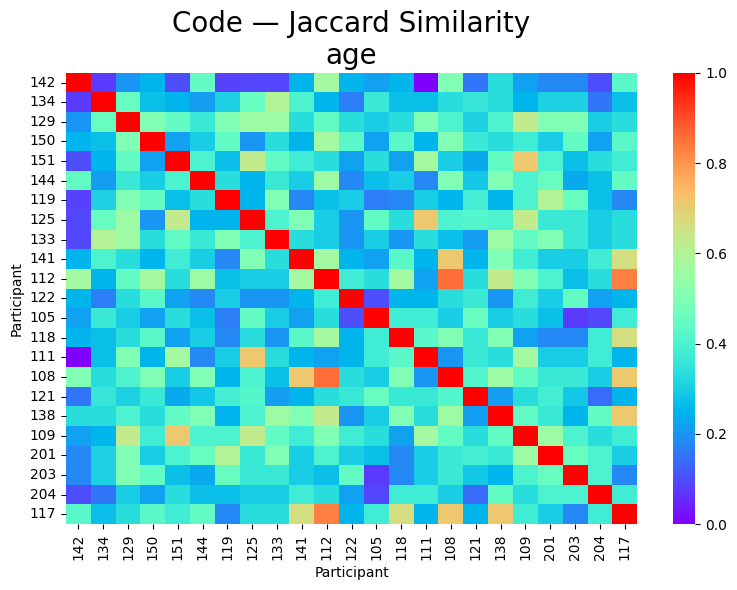

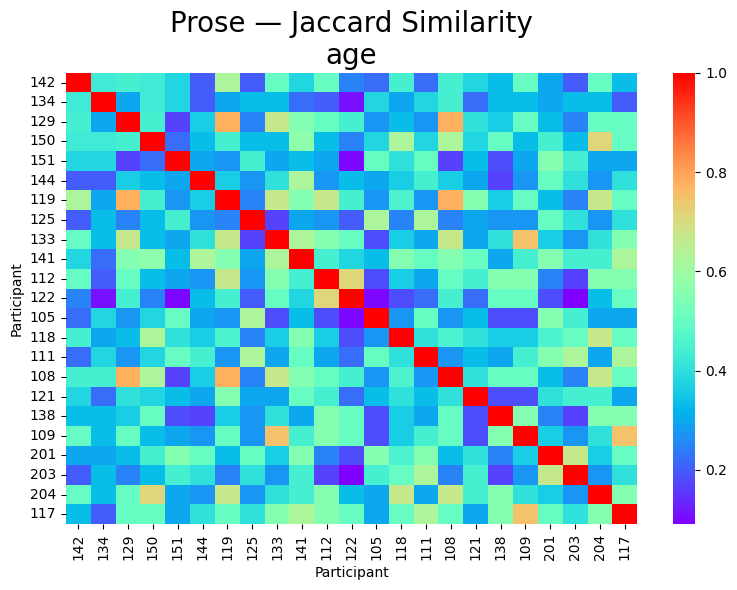

In [92]:
create_jaccard_matrix('code', sort_by='age')
create_jaccard_matrix('prose', sort_by='age')

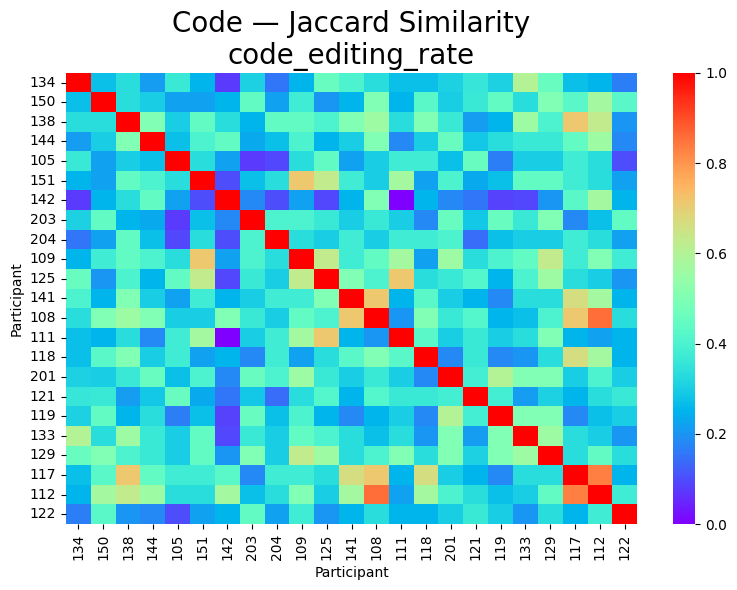

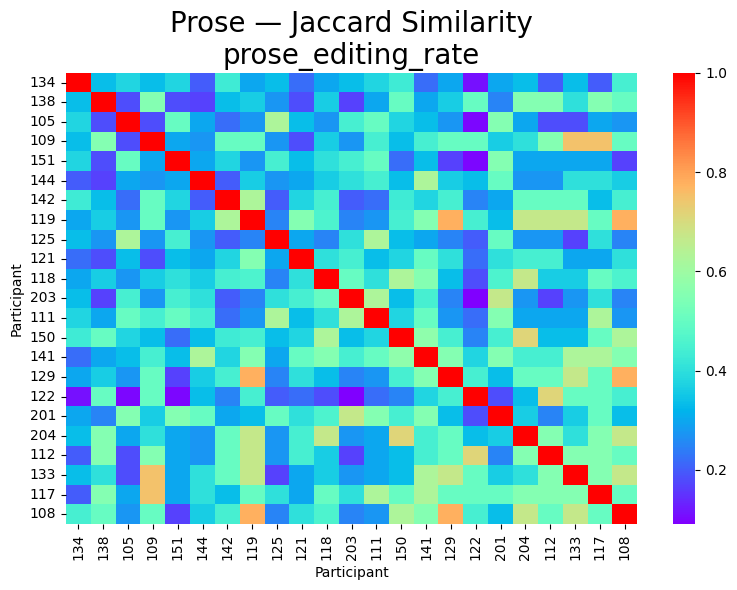

In [96]:
create_jaccard_matrix('code', sort_by='code_editing_rate')
create_jaccard_matrix('prose', sort_by='prose_editing_rate')

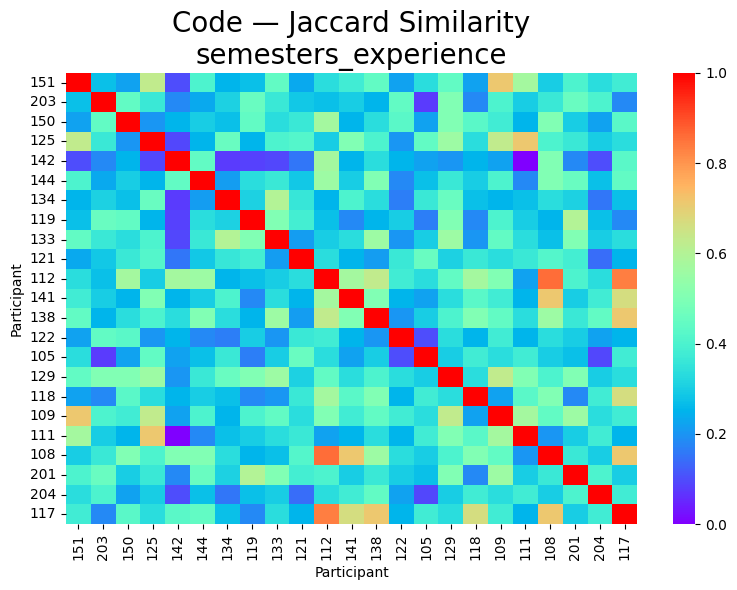

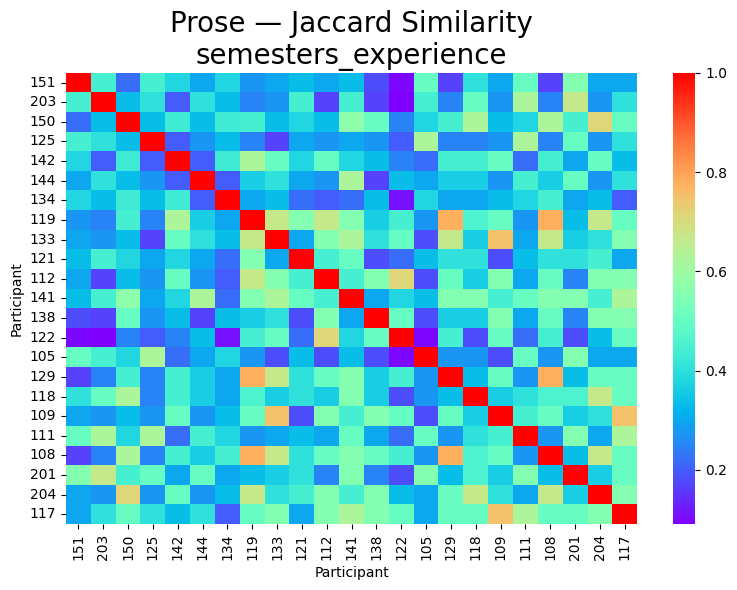

In [94]:
create_jaccard_matrix('code', sort_by='semesters_experience')
create_jaccard_matrix('prose', sort_by='semesters_experience')

In [89]:

# # Individual plot per row (first 5)
# for idx, row in df.head(5).iterrows():
#     region_counts = row['top_HarvOx_regions']
#     sorted_regions = sorted(region_counts.items(), key=lambda x: x[1], reverse=True)
#     regions, counts = zip(*sorted_regions) if sorted_regions else ([], [])

#     fig, ax = plt.subplots(figsize=(10, 5))
#     ax.bar(range(len(regions)), counts, color=sns.color_palette("tab10", len(regions)))
#     ax.set_xticks(range(len(regions)))
#     ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
#     ax.set_title(f"Row {idx} — {row.get('layer', '')} | Top HarvOx Region Counts")
#     ax.set_ylabel("Count")
#     ax.set_xlabel("Region")
#     ax.set_ylim([0,800])
#     plt.tight_layout()
#     plt.show()

# # Aggregated across all layers
# aggregated = Counter()
# for region_counts in df['top_HarvOx_regions']:
#     aggregated.update(region_counts)

# sorted_agg = sorted(aggregated.items(), key=lambda x: x[1], reverse=True)
# regions, counts = zip(*sorted_agg)

# fig, ax = plt.subplots(figsize=(14, 6))
# ax.bar(range(len(regions)), counts, color=sns.color_palette("tab20", len(regions)))
# ax.set_xticks(range(len(regions)))
# ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
# ax.set_title("Aggregated HarvOx Region Counts Across All Layers")
# ax.set_ylabel("Total Count")
# # ax.set_ylim([0,800])
# ax.set_xlabel("Region")
# plt.tight_layout()
# plt.show()
